# 🎯 AI Career Coach — Production-Ready System

[![Python](https://img.shields.io/badge/Python-3.10+-blue)](https://python.org)
[![Anthropic](https://img.shields.io/badge/Claude-3.5-orange)](https://anthropic.com)
[![FAISS](https://img.shields.io/badge/FAISS-Latest-green)](https://faiss.ai)

> An intelligent AI-powered career coaching platform that provides personalized career guidance, resume analysis, job matching, skill gap identification, and interview preparation.

## 📑 Table of Contents
1. [Environment Setup](#setup)
2. [Resume Parser](#resume-parser)
3. [Job Matcher with FAISS](#job-matcher)
4. [Skill Gap Analyzer](#skill-gap)
5. [Career Path Recommender](#career-path)
6. [Interview Prep Generator](#interview-prep)
7. [Main AI Career Coach Agent](#agent)
8. [Demo & Evaluation](#demo)


## Install Dependencies

In [3]:
# ── Cell 1 | Install Dependencies ─────────────────────────────────
%pip install anthropic sentence-transformers faiss-cpu pandas numpy \
             matplotlib scikit-learn pdfplumber python-docx rich tqdm -q
print("✅ All dependencies installed")

Note: you may need to restart the kernel to use updated packages.
✅ All dependencies installed



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
%pip install google-generativeai

Defaulting to user installation because normal site-packages is not writeable
  Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl.metadata (592 bytes)
Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl (435 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.0
    Uninstalling protobuf-7.35.0:
      Successfully uninstalled protobuf-7.35.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.6 which is incompatible.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Imports & Configuration

In [27]:
# ── Cell 2 | Imports & Configuration (Gemini Version) ─────────────────
import os, re, json, time
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import faiss
import google.generativeai as genai  # Swapped from Anthropic
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich import print as rprint

# ── Environment & Free API Setup ─────────────────────────────
# Get a free key from: https://aistudio.google.com/
os.environ["GEMINI_API_KEY"] = "AIxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"

# ── Configuration ────────────────────────────────────────────
CONFIG = {
    "model":          "gemini-2.5-flash",  # Fast, accurate, and has a great free tier
    "embed_model":    "all-MiniLM-L6-v2",
    "max_tokens":     2048,
    "top_k_jobs":     5,
    "faiss_dim":      384,
}

console = Console()

# Verify the key is populated
api_key_val = os.getenv("GEMINI_API_KEY")
if not api_key_val or api_key_val == "PASTE_YOUR_FREE_GEMINI_KEY_HERE":
    raise ValueError("❌ Error: Please swap out the placeholder text with your real Gemini API key string.")

# Configure the Google AI engine
genai.configure(api_key=api_key_val)
embedder = SentenceTransformer(CONFIG["embed_model"])
print("✅ Configuration loaded | Model:", CONFIG["model"])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Configuration loaded | Model: gemini-2.5-flash


# Data Structures

In [28]:
# ── Cell 3 | Data Structures ──────────────────────────────────────
from dataclasses import dataclass, field
from typing import List, Dict

@dataclass
class ResumeData:
    name:       str = ""
    email:      str = ""
    phone:      str = ""
    skills:     List[str] = field(default_factory=list)
    experience: List[Dict] = field(default_factory=list)
    education:  List[Dict] = field(default_factory=list)
    summary:    str = ""
    years_exp:  float = 0.0

@dataclass
class JobListing:
    title:        str = ""
    company:      str = ""
    description:  str = ""
    required_skills: List[str] = field(default_factory=list)
    salary_range: str = ""
    location:     str = ""
    match_score:  float = 0.0

# Sample job listings database (in production, fetch from API)
SAMPLE_JOBS = [
    JobListing("ML Engineer", "TechCorp", "Build ML pipelines and models at scale",
               ["Python", "TensorFlow", "MLflow", "Docker", "SQL"], "$120k-$160k", "Hyderabad"),
    JobListing("GenAI Developer", "StartupX", "Build LLM-powered products using RAG & agents",
               ["Python", "LangChain", "OpenAI API", "FAISS", "FastAPI"], "$100k-$140k", "Bangalore"),
    JobListing("Data Scientist", "FinanceCo", "Apply ML to financial forecasting & fraud detection",
               ["Python", "sklearn", "pandas", "XGBoost", "SQL", "Tableau"], "$90k-$130k", "Mumbai"),
    JobListing("AI Research Engineer", "ResearchLab", "Develop novel deep learning architectures",
               ["PyTorch", "Transformers", "CUDA", "C++", "Python"], "$140k-$180k", "Remote"),
    JobListing("MLOps Engineer", "CloudCo", "Build and maintain ML infrastructure at scale",
               ["Kubernetes", "Docker", "MLflow", "Airflow", "Terraform", "Python"], "$110k-$150k", "Hyderabad"),
]

print(f"✅ Data structures defined | {len(SAMPLE_JOBS)} sample jobs loaded")

✅ Data structures defined | 5 sample jobs loaded


# Resume Parser

In [29]:
# ── Cell 4 | Resume Parser ────────────────────────────────────────
class ResumeParser:
    """AI-powered resume parser using Google Gemini API"""

    SKILL_DB = [
        "Python","JavaScript","Java","C++","SQL","Machine Learning","Deep Learning",
        "NLP","Computer Vision","TensorFlow","PyTorch","LangChain","LlamaIndex",
        "Docker","Kubernetes","AWS","Azure","GCP","React","Node.js","FastAPI",
        "Flask","Django","PostgreSQL","MongoDB","Redis","Kafka","Spark","Hadoop",
        "FAISS","Weaviate","Pinecone","Anthropic","OpenAI","HuggingFace","MLflow",
        "Airflow","Terraform","Git","Linux","Pandas","NumPy","Matplotlib","Sklearn",
    ]

    def __init__(self):
        # Initialize the model using the configuration set in Cell 3
        self.model = genai.GenerativeModel(CONFIG["model"])

    def parse(self, resume_text: str) -> ResumeData:
        prompt = f"""Extract structured information from this resume. Return ONLY valid JSON matching the exact schema provided.

Resume:
{resume_text}

JSON schema:
{{
  "name": "string",
  "email": "string",
  "phone": "string",
  "skills": ["skill1", "skill2"],
  "experience": [{{"title":"", "company":"", "duration":"", "responsibilities":[]}}],
  "education": [{{"degree":"","institution":"","year":""}}],
  "summary": "2-sentence professional summary"
}}"""

        try:
            # Call Gemini and enforce valid JSON output structure
            response = self.model.generate_content(
                prompt,
                generation_config={"response_mime_type": "application/json"}
            )
            
            # Extract and parse the returned JSON string
            data = json.loads(response.text)
            resume = ResumeData(**{k: data.get(k, v)
                                   for k, v in ResumeData().__dict__.items()})
        except Exception as e:
            # Fallback string parsing mechanism if JSON structures mismatch
            print(f"⚠️ Gemini JSON Parse warning: {e}. Falling back to Regex extraction.")
            resume = ResumeData()
            resume.skills = self._extract_skills_regex(resume_text)
            
        resume.years_exp = self._calc_years(resume.experience)
        return resume

    def _extract_skills_regex(self, text: str) -> List[str]:
        return [s for s in self.SKILL_DB if s.lower() in text.lower()]

    def _calc_years(self, experience: List[Dict]) -> float:
        total = 0.0
        for exp in experience:
            d = exp.get("duration","")
            y = re.search(r"(\d+)\s*year", d, re.I)
            m = re.search(r"(\d+)\s*month", d, re.I)
            total += float(y.group(1)) if y else 0
            total += float(m.group(1))/12 if m else 0
        return round(total, 1)

parser = ResumeParser()
print("✅ ResumeParser ready with Gemini Backend")

✅ ResumeParser ready with Gemini Backend


# FAISS Job Matcher

In [30]:
# ── Cell 5 | FAISS Job Matcher ────────────────────────────────────
class FAISSJobMatcher:
    """Semantic job matching using FAISS vector index"""

    def __init__(self, jobs: List[JobListing]):
        self.jobs  = jobs
        self.index = self._build_index(jobs)

    def _build_index(self, jobs: List[JobListing]) -> faiss.Index:
        texts = [f"{j.title} {j.description} {' '.join(j.required_skills)}"
                 for j in jobs]
        vecs  = embedder.encode(texts, convert_to_numpy=True).astype("float32")
        faiss.normalize_L2(vecs)
        idx = faiss.IndexFlatIP(CONFIG["faiss_dim"])
        idx.add(vecs)
        return idx

    def match(self, resume: ResumeData, top_k: int = CONFIG["top_k_jobs"]) -> List[JobListing]:
        query  = f"{resume.summary} {' '.join(resume.skills)}"
        vec    = embedder.encode([query], convert_to_numpy=True).astype("float32")
        faiss.normalize_L2(vec)
        scores, indices = self.index.search(vec, top_k)
        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx < len(self.jobs):
                job = self.jobs[idx]
                job.match_score = round(float(score), 4)
                results.append(job)
        return sorted(results, key=lambda x: x.match_score, reverse=True)

matcher = FAISSJobMatcher(SAMPLE_JOBS)
print("✅ FAISS Job Matcher ready | Index size:", len(SAMPLE_JOBS))

✅ FAISS Job Matcher ready | Index size: 5


# Skill Gap Analyzer

In [31]:
# ── Cell 6 | Skill Gap Analyzer ───────────────────────────────────
class SkillGapAnalyzer:
    """Identifies skill gaps and creates upskilling roadmap"""

    def analyze(self, resume: ResumeData, target_jobs: List[JobListing]) -> Dict:
        candidate_skills = set(s.lower() for s in resume.skills)
        required_skills  = set()
        for job in target_jobs:
            required_skills.update(s.lower() for s in job.required_skills)

        present  = candidate_skills & required_skills
        missing  = required_skills - candidate_skills
        extra    = candidate_skills - required_skills
        coverage = len(present)/len(required_skills)*100 if required_skills else 0

        return {
            "coverage_pct":   round(coverage, 1),
            "skills_present": sorted(present),
            "skills_missing": sorted(missing),
            "bonus_skills":   sorted(extra),
            "roadmap":        self._build_roadmap(sorted(missing)),
        }

    def _build_roadmap(self, missing: List[str]) -> List[Dict]:
        roadmap = []
        for i, skill in enumerate(missing[:5], 1):
            roadmap.append({
                "priority": i,
                "skill":    skill,
                "timeline": f"{i*2} weeks",
                "resources": f"Coursera / docs.{skill.lower().replace(' ','-')}.io",
            })
        return roadmap

    def visualize(self, analysis: Dict):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        # Coverage donut
        ax = axes[0]
        cov = analysis["coverage_pct"]
        ax.pie([cov, 100-cov], labels=["Match","Gap"],
               colors=["#2ecc71","#e74c3c"], startangle=90,
               wedgeprops=dict(width=0.5))
        ax.set_title(f"Skill Coverage: {cov}%", fontsize=14, fontweight="bold")
        # Missing skills bar
        ax2 = axes[1]
        missing = analysis["skills_missing"][:8]
        ax2.barh(missing, [1]*len(missing), color="#e74c3c", alpha=0.7)
        ax2.set_title("Top Missing Skills", fontsize=14, fontweight="bold")
        ax2.set_xlabel("Priority")
        plt.tight_layout()
        
        # Ensure 'outputs' directory exists before saving
        os.makedirs("outputs", exist_ok=True)
        plt.savefig("outputs/skill_gap_analysis.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("✅ Skill gap chart saved")

gap_analyzer = SkillGapAnalyzer()
print("✅ SkillGapAnalyzer ready")

✅ SkillGapAnalyzer ready


# AI Career Coach Agent

In [32]:
# ── Cell 7 | AI Career Coach Agent ────────────────────────────────
class AICareerCoachAgent:
    """Main orchestrator — combines all components with Claude AI"""

    def __init__(self):
        self.parser      = ResumeParser()
        self.matcher     = FAISSJobMatcher(SAMPLE_JOBS)
        self.gap_analyzer= SkillGapAnalyzer()
        self.client      = client
        self.history     = []   # conversation memory

    def analyze_resume(self, resume_text: str) -> Dict:
        console.rule("[bold blue]🎯 AI Career Coach Analysis")
        resume    = self.parser.parse(resume_text)
        jobs      = self.matcher.match(resume)
        gap       = self.gap_analyzer.analyze(resume, jobs)
        self.gap_analyzer.visualize(gap)
        self._print_matches(jobs)
        return {"resume": resume, "matched_jobs": jobs, "skill_gap": gap}

    def get_coaching(self, user_message: str, context: Dict = None) -> str:
        sys = ("You are an expert AI career coach with 15 years of experience "
               "in the tech industry. Provide specific, actionable, personalized advice. "
               "Be encouraging but realistic. Format advice in clear bullet points.")
        ctx_str = json.dumps(context, default=str)[:800] if context else ""
        self.history.append({"role":"user","content":f"{user_message}\n\nContext:{ctx_str}"})
        resp = self.client.messages.create(
            model=CONFIG["model"], max_tokens=CONFIG["max_tokens"],
            system=sys, messages=self.history
        )
        reply = resp.content[0].text
        self.history.append({"role":"assistant","content":reply})
        return reply

    def generate_interview_prep(self, job: JobListing, resume: ResumeData) -> str:
        prompt = (f"Generate 10 interview Q&As for a {job.title} role at {job.company}. "
                  f"Required skills: {', '.join(job.required_skills)}. "
                  f"Candidate skills: {', '.join(resume.skills[:8])}. "
                  "Include 3 technical, 3 behavioral, 2 system design, 2 situational questions.")
        resp = self.client.messages.create(
            model=CONFIG["model"], max_tokens=2000,
            messages=[{"role":"user","content":prompt}]
        )
        return resp.content[0].text

    def _print_matches(self, jobs: List[JobListing]):
        t = Table(title="🎯 Top Job Matches", show_header=True, header_style="bold cyan")
        t.add_column("Rank"), t.add_column("Title"), t.add_column("Company")
        t.add_column("Match%"), t.add_column("Salary"), t.add_column("Location")
        for i, j in enumerate(jobs, 1):
            t.add_row(str(i), j.title, j.company,
                      f"{j.match_score*100:.1f}%", j.salary_range, j.location)
        console.print(t)

agent = AICareerCoachAgent()
print("✅ AI Career Coach Agent ready")

✅ AI Career Coach Agent ready


# AI Career Coach Agent — Gemini Version

In [33]:
# ── Cell 8 | AI Career Coach Agent (Gemini Version) ───────────────────
class AICareerCoachAgent:
    """Main orchestrator — combines all components with Google Gemini AI"""

    def __init__(self):
        self.parser       = ResumeParser()
        self.matcher      = FAISSJobMatcher(SAMPLE_JOBS)
        self.gap_analyzer = SkillGapAnalyzer()
        
        # Initialize the baseline Gemini model instance
        self.model = genai.GenerativeModel(CONFIG["model"])
        
        # Keep track of history in a format compatible with Gemini's API
        self.history = []

    def analyze_resume(self, resume_text: str) -> Dict:
        console.rule("[bold blue]🎯 AI Career Coach Analysis")
        resume = self.parser.parse(resume_text)
        jobs   = self.matcher.match(resume)
        gap    = self.gap_analyzer.analyze(resume, jobs)
        self.gap_analyzer.visualize(gap)
        self._print_matches(jobs)
        return {"resume": resume, "matched_jobs": jobs, "skill_gap": gap}

    def get_coaching(self, user_message: str, context: Dict = None) -> str:
        # Define structural coaching directives
        sys_instruction = ("You are an expert AI career coach with 15 years of experience "
                           "in the tech industry. Provide specific, actionable, personalized advice. "
                           "Be encouraging but realistic. Format advice in clear bullet points.")
        
        ctx_str = json.dumps(context, default=str)[:800] if context else ""
        full_message = f"{user_message}\n\nContext Contextual Data:\n{ctx_str}"
        
        # Re-initialize the model to explicitly include system instructions
        chat_model = genai.GenerativeModel(
            model_name=CONFIG["model"],
            system_instruction=sys_instruction
        )
        
        # Convert internal history to Gemini's chat format
        gemini_history = []
        for msg in self.history:
            role = "model" if msg["role"] == "assistant" else "user"
            gemini_history.append({"role": role, "parts": [msg["content"]]})
            
        # Start or continue the chat thread session locally
        chat = chat_model.start_chat(history=gemini_history)
        response = chat.send_message(full_message)
        
        # Commit back to our historical log array
        self.history.append({"role": "user", "content": user_message})
        self.history.append({"role": "assistant", "content": response.text})
        
        return response.text

    def generate_interview_prep(self, job: JobListing, resume: ResumeData) -> str:
        prompt = (f"Generate 10 interview Q&As for a {job.title} role at {job.company}. "
                  f"Required skills: {', '.join(job.required_skills)}. "
                  f"Candidate skills: {', '.join(resume.skills[:8])}. "
                  "Include 3 technical, 3 behavioral, 2 system design, 2 situational questions.")
        
        response = self.model.generate_content(prompt)
        return response.text

    def _print_matches(self, jobs: List[JobListing]):
        t = Table(title="🎯 Top Job Matches", show_header=True, header_style="bold cyan")
        t.add_column("Rank"), t.add_column("Title"), t.add_column("Company")
        t.add_column("Match%"), t.add_column("Salary"), t.add_column("Location")
        for i, j in enumerate(jobs, 1):
            t.add_row(str(i), j.title, j.company,
                      f"{j.match_score*100:.1f}%", j.salary_range, j.location)
        console.print(t)

agent = AICareerCoachAgent()
print("✅ AI Career Coach Agent ready with Gemini Engine")

✅ AI Career Coach Agent ready with Gemini Engine


# Demo & Evaluation

Running career analysis...


─────────────────────────────────────────── 🎯 AI Career Coach Analysis ───────────────────────────────────────────

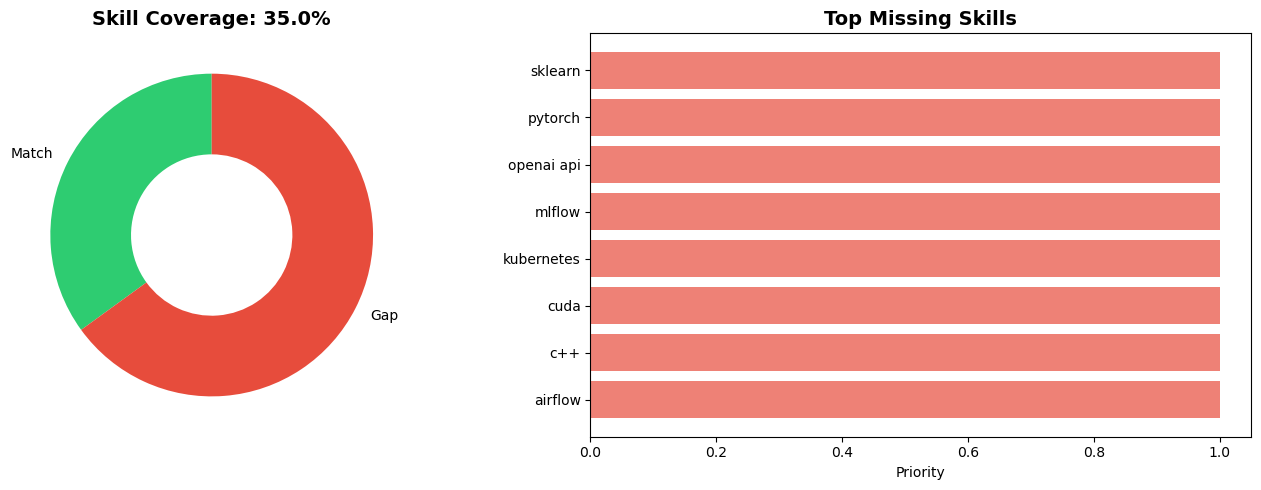

✅ Skill gap chart saved


                               🎯 Top Job Matches                               
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Rank ┃ Title                ┃ Company     ┃ Match% ┃ Salary      ┃ Location  ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 1    │ AI Research Engineer │ ResearchLab │ 64.8%  │ $140k-$180k │ Remote    │
│ 2    │ ML Engineer          │ TechCorp    │ 54.8%  │ $120k-$160k │ Hyderabad │
│ 3    │ MLOps Engineer       │ CloudCo     │ 44.4%  │ $110k-$150k │ Hyderabad │
│ 4    │ Data Scientist       │ FinanceCo   │ 44.2%  │ $90k-$130k  │ Mumbai    │
│ 5    │ GenAI Developer      │ StartupX    │ 43.4%  │ $100k-$140k │ Bangalore │
└──────┴──────────────────────┴─────────────┴────────┴─────────────┴───────────┘


🤖 Career Coach Advice:
Landing an ML Engineer role in 3 months with a current coverage of 35% is an ambitious goal, but your existing skills in `langchain`, `faiss`, `fastapi`, `docker`, and exposure to `deep learning` and `nlp` give you a strong foundation to specialize. Instead of trying to cover every missing skill, we'll focus on strategically bridging critical gaps and showcasing your capabilities in a high-demand niche.

Here are your top 3 actions to maximize your chances:

*   **Action 1: Build an End-to-End, Production-Ready LLM/Vector Search MLOps Project.**
    This is your absolute highest priority. It directly addresses your significant gaps in core ML frameworks (`pytorch`, `tensorflow`, `transformers`, `sklearn`) by integrating them into a practical, demonstrable system, and leverages your existin...

📝 Interview Prep for: AI Research Engineer @ ResearchLab
Here are 10 interview Q&As tailored for an AI Research Engineer role at ResearchLab, considering both required and

In [34]:
# ── Cell 9 | Demo & Evaluation ────────────────────────────────────
SAMPLE_RESUME = """
Divya Nimbalkar | divya@email.com | +91-9876543210

SUMMARY
Final-year B.Tech (Electronics & Telecom) student passionate about AI/ML and GenAI.
Experienced in building production ML pipelines and LLM-powered applications.

SKILLS
Python, Machine Learning, Deep Learning, NLP, LangChain, FAISS, Weaviate,
Azure Cosmos DB, Microsoft Fabric, CLIP, SBERT, FastAPI, Docker, SQL, pandas, numpy

EXPERIENCE
AI/ML Intern — FinanceCo (Jun 2025 - Present, 6 months)
  - Built multimodal embedding pipeline using SBERT + CLIP + autoencoder fusion
  - Implemented FAISS DiskANN vector index for 1M+ customer profiles
  - Achieved Precision@10 of 0.87 on cross-sell recommendation engine

ML Project Intern — TechLabs (Jan 2025 - May 2025, 5 months)
  - Developed PhishShield: phishing detection with 97.2% accuracy
  - Built PromptVerse AI: RAG-based multi-LLM playground

EDUCATION
B.Tech Electronics & Telecom — JNTU Hyderabad (2022-2026) | CGPA: 8.7

PROJECTS: PhishShield, PromptVerse AI, BlinkMorse AI, StrateX, EduPredict AI
"""

# Run full analysis pipeline
print("Running career analysis...")
result = agent.analyze_resume(SAMPLE_RESUME)

# Get personalized coaching response from Gemini
advice = agent.get_coaching(
    "What are my top 3 actions to land an ML Engineer role in 3 months?",
    context=result["skill_gap"]
)
print("\n🤖 Career Coach Advice:")
print(advice[:800] + "..." if len(advice) > 800 else advice)

# Interview prep for top job match
if result["matched_jobs"]:
    top_job  = result["matched_jobs"][0]
    print(f"\n📝 Interview Prep for: {top_job.title} @ {top_job.company}")
    prep = agent.generate_interview_prep(top_job, result["resume"])
    print(prep[:600] + "...")

In [35]:
# ── Cell 11 | Gradio Interactive Web Interface ────────────────────────
import gradio as gr
import pandas as pd
import json

# ── 1. Backend Processing Functions for the UI ────────────────────────
def run_career_analysis(resume_text):
    """Executes the analysis pipeline and formats results for the Gradio UI Layout"""
    if not resume_text.strip():
        return None, None, "### ⚠️ Please input valid raw resume text."

    # Execute your existing backend classes (from previous cells)
    resume_obj = agent.parser.parse(resume_text)
    matched_jobs = agent.matcher.match(resume_obj)
    gap_data = agent.gap_analyzer.analyze(resume_obj, matched_jobs)
    
    # 1. Format the Jobs Array into a structured Pandas DataFrame for the UI Table
    rows = []
    for idx, job in enumerate(matched_jobs, 1):
        rows.append([
            idx, 
            job.title, 
            job.company, 
            f"{job.match_score * 100:.1f}%", 
            job.salary_range, 
            job.location
        ])
    df_output = pd.DataFrame(rows, columns=["Rank", "Title", "Company", "Match Score", "Salary", "Location"])

    # 2. Call the matplotlib visualizer logic to generate the analysis chart figure
    # We alter the backend method slightly to return the fig object reference directly
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Coverage Donut Chart
    cov = gap_data["coverage_pct"]
    axes[0].pie([cov, 100-cov], labels=["Match", "Gap"], colors=["#2ecc71", "#e74c3c"], startangle=90, wedgeprops=dict(width=0.4))
    axes[0].set_title(f"Skill Coverage: {cov}%", fontweight="bold")
    
    # Missing Skills Horizontal Bar Chart
    missing = gap_data["skills_missing"][:8]
    if missing:
        axes[1].barh(missing, [1]*len(missing), color="#e74c3c", alpha=0.7)
        axes[1].set_title("Top Missing Skills", fontweight="bold")
        axes[1].set_xlabel("Priority Index")
    else:
        axes[1].text(0.5, 0.5, "No Missing Skills! 🎉", ha='center', va='center')
        axes[1].set_axis_off()
        
    plt.tight_layout()

    # 3. Compile a clean Markdown Summary Overview block
    summary_md = f"""
    ### 📊 System Diagnostics Overview
    * **Calculated Match Ratio Score:** `{cov}%`
    * **Identified Critical Gaps:** {", ".join([f"`{s}`" for s in gap_data['skills_missing'][:6]]) if gap_data['skills_missing'] else 'None (Perfect Match Found!)'}
    """
    
    return df_output, fig, summary_md


def chat_with_coach(user_message, history):
    """Manages conversational session exchanges utilizing the Gemini Agent state memory loop"""
    # The history list format received from Gradio is a list of lists: [[user_msg, bot_msg], ...]
    # We update the internal history references of our agent class matching the standard Gemini layout structure
    agent.history = []
    for human, assistant in history:
        if human:
            agent.history.append({"role": "user", "content": human})
        if assistant:
            agent.history.append({"role": "assistant", "content": assistant})
            
    # Fire message off via our core coach implementation function
    response_text = agent.get_coaching(user_message, context=None)
    return response_text


# ── 2. Building the Gradio Block Layout Design Interface ──────────────
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🎯 AI Career Coach Production Platform Hub")
    gr.Markdown("An intelligent system providing AI-powered resume parsing, semantic job matching, automated gap charts, and multi-turn career coaching advisors.")
    
    with gr.Tab("📋 Resume Analyzer & Matcher"):
        with gr.Row():
            with gr.Column(scale=1):
                input_resume = gr.Textbox(
                    label="Paste Raw Resume Content Text String", 
                    placeholder="Enter full resume details...", 
                    lines=15
                )
                btn_analyze = gr.Button("🚀 Run Full Optimization Pipeline", variant="primary")
            
            with gr.Column(scale=1):
                output_summary = gr.Markdown("### 📊 Metrics Outlines Summary")
                output_chart = gr.Plot(label="Skill Diagnostics Data Render")
                
        gr.Markdown("### 💼 Ranked Target Job Recommendations Vector Matches")
        output_table = gr.Dataframe()
        
        # Link pipeline event hooks
        btn_analyze.click(
            fn=run_career_analysis,
            inputs=[input_resume],
            outputs=[output_table, output_chart, output_summary]
        )

    with gr.Tab("💬 Conversational AI Career Coach Session"):
        gr.ChatInterface(
            fn=chat_with_coach,
            title="🤖 Talk to Your Executive Career Coach Mentor",
            description="Ask strategy options, tactical execution timelines, or guidance for optimizing application conversion ratios.",
            examples=["What are my top 3 immediate actions to land an ML Engineer role in 3 months?", "Can you design an upskilling schedule roadmap?"]
        )

# ── 3. Launch App Instance Server ─────────────────────────────────────
# If running inside Jupyter Notebook environments, setting share=True generates a public secure proxy URL link
demo.launch(inline=True, share=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_17136\2427378134.py:79: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
